In [30]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os


In [31]:
# Create output folder if it doesn't exist
os.makedirs("output", exist_ok=True)

# DATA LOADING
file = "data/000003.bin"
points_raw = np.fromfile(file, dtype=np.float32).reshape(-1, 4) # Each point has 4 values: X, Y, Z and reflectivity. We are only going to use the first 3 (X,Y,Z)
points_xyz = points_raw[:, :3]


--- STARTING ADAS PIPELINE ---
Original cloud loaded: 113110 points.


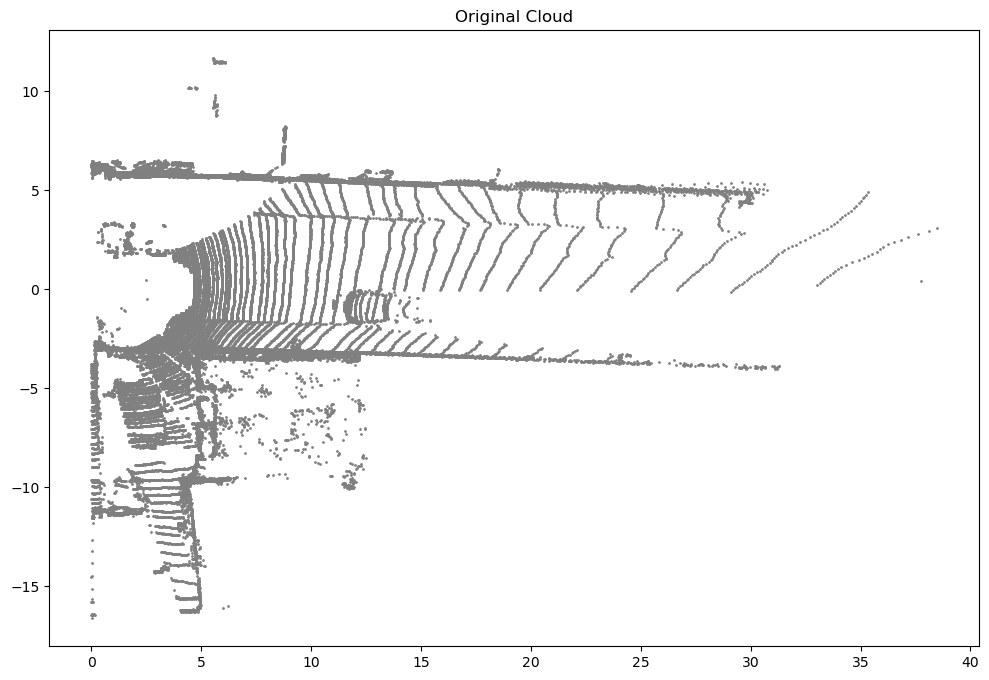

In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_xyz)
print(f"Original cloud loaded: {len(pcd.points)} points.")

# Save image step 1
plt.figure(figsize=(12, 8))
pts = np.asarray(pcd.points)
mask = (pts[:, 0] > 0) & (pts[:, 0] < 40) & (np.abs(pts[:, 1]) < 20)
plt.scatter(pts[mask, 0], pts[mask, 1], c='gray', s=1)
plt.title("Original Cloud")
plt.savefig("output/01_original.png", bbox_inches='tight')
plt.show()
plt.close()

Points after Voxel Grid: 29798
   -> We have reduced the information by 73.7%


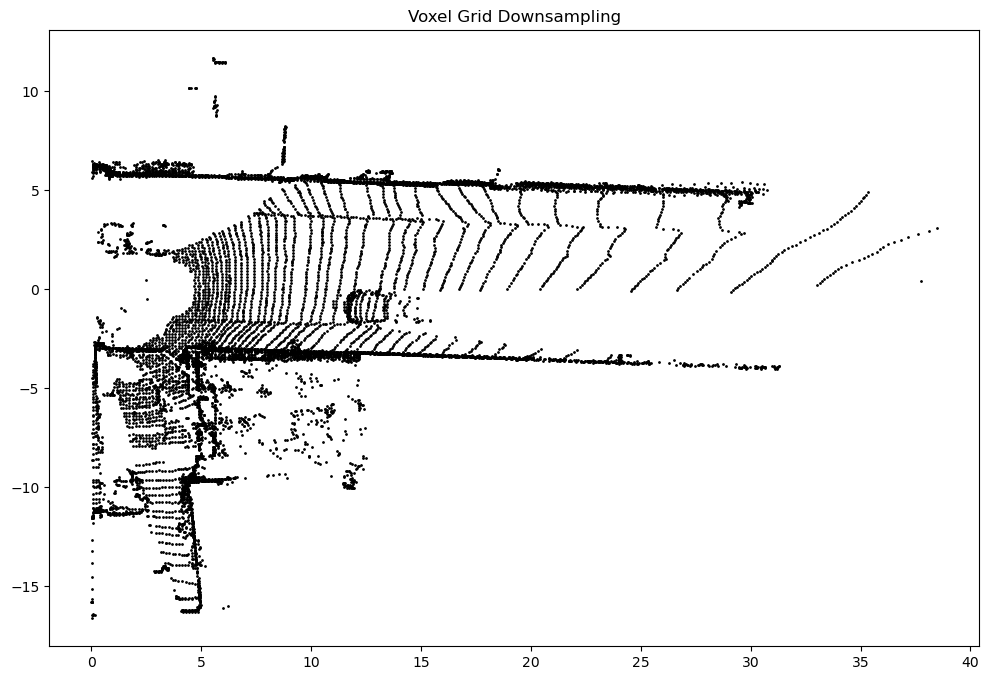

In [ ]:
# VOXEL GRID DOWNSAMPLING
pcd_reduced = pcd.voxel_down_sample(voxel_size=0.15) # Each cube measures 15x15x15

print(f"Points after Voxel Grid: {len(pcd_reduced.points)}")
reduction = 100 - (len(pcd_reduced.points) / len(pcd.points) * 100)
print(f"   -> We have reduced the information by {reduction:.1f}%")

# Save image step 2
plt.figure(figsize=(12, 8))
pts_vox = np.asarray(pcd_reduced.points)
mask_vox = (pts_vox[:, 0] > 0) & (pts_vox[:, 0] < 40) & (np.abs(pts_vox[:, 1]) < 20)
plt.scatter(pts_vox[mask_vox, 0], pts_vox[mask_vox, 1], c='black', s=1)
plt.title("Voxel Grid Downsampling")
plt.savefig("output/02_voxel.png", bbox_inches='tight')
plt.show()
plt.close()


RANSAC applied. Ground points removed: 9183
   -> Remaining floating points (obstacles): 20615


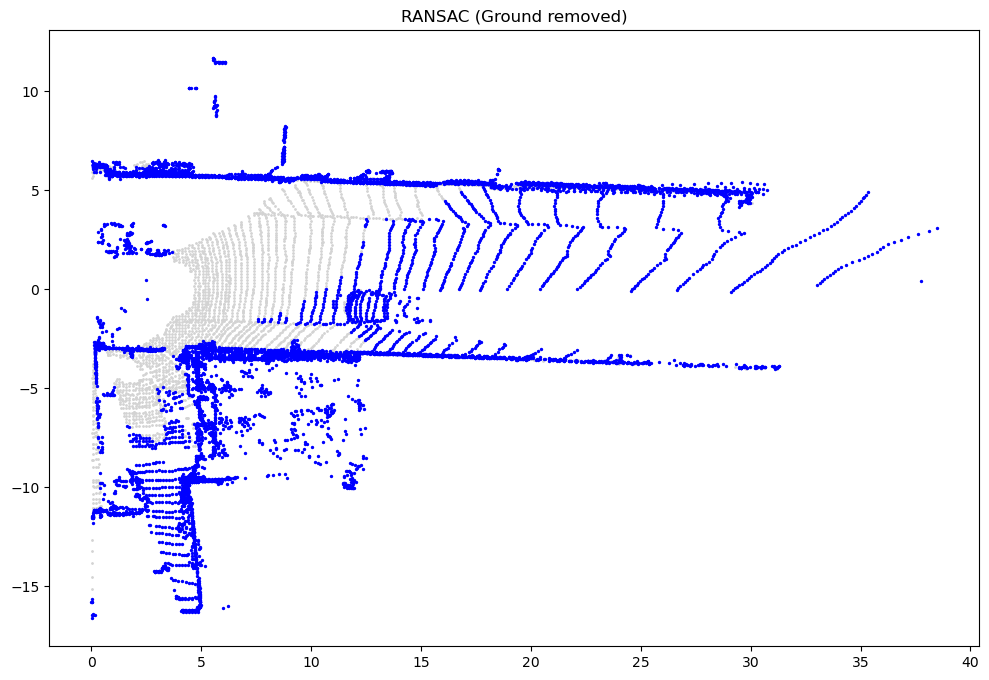

In [34]:
# RANSAC (Remove the ground)
plane_model, inliers = pcd_reduced.segment_plane(
    distance_threshold=0.25, # Maximum distance a point can be from the plane to be considered "ground". Here we give it a 25cm margin in case of potholes.
    ransac_n=3,              # Number of points used to generate the plane
    num_iterations=500       # Iterations
)

# We separate the inliers (ground) from the outliers (protruding obstacles)
cloud_ground = pcd_reduced.select_by_index(inliers)
cloud_obstacles = pcd_reduced.select_by_index(inliers, invert=True)

print(f"RANSAC applied. Ground points removed: {len(cloud_ground.points)}")
print(f"   -> Remaining floating points (obstacles): {len(cloud_obstacles.points)}")

# Save image step 3
plt.figure(figsize=(12, 8))
pts_ground = np.asarray(cloud_ground.points)
pts_obs = np.asarray(cloud_obstacles.points)
mask_ground = (pts_ground[:, 0] > 0) & (pts_ground[:, 0] < 40) & (np.abs(pts_ground[:, 1]) < 20)
mask_obs = (pts_obs[:, 0] > 0) & (pts_obs[:, 0] < 40) & (np.abs(pts_obs[:, 1]) < 20)
plt.scatter(pts_ground[mask_ground, 0], pts_ground[mask_ground, 1], c='lightgray', s=1)
plt.scatter(pts_obs[mask_obs, 0], pts_obs[mask_obs, 1], c='blue', s=2)
plt.title("RANSAC (Ground removed)")
plt.savefig("output/03_ransac.png", bbox_inches='tight')
plt.show()
plt.close()

DBSCAN applied. 50 objects/clusters have been detected.


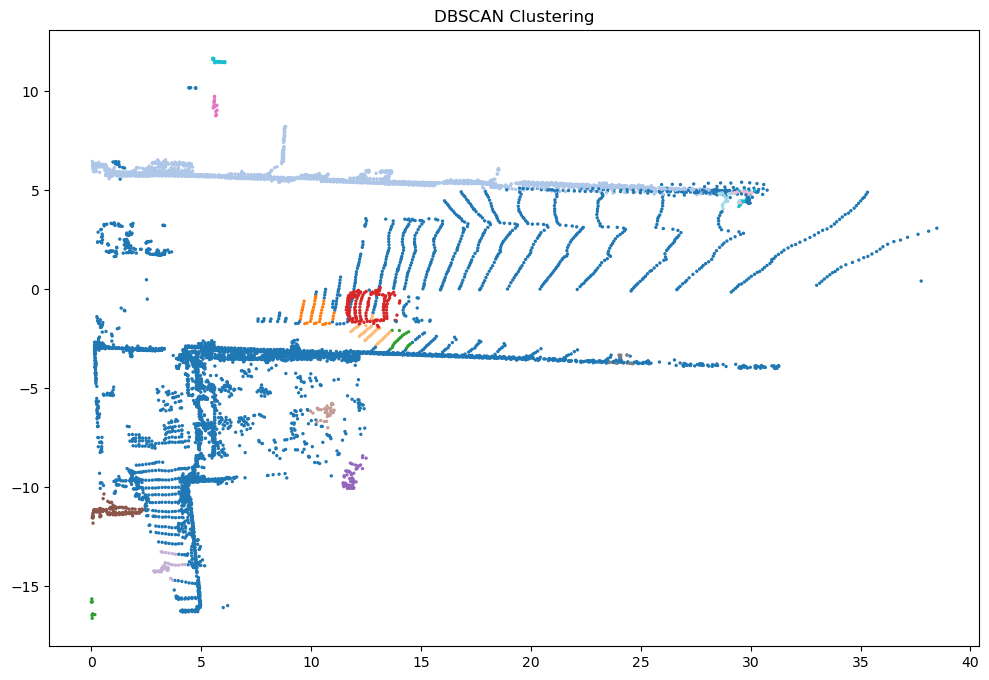

In [35]:

# DBSCAN (CLUSTERING)
labels = np.array(cloud_obstacles.cluster_dbscan(eps=0.6, # Neighborhood distance
                                                 min_points=20 # Minimum neighbors to be relevant
                                                 ))
max_label = labels.max()
print(f"DBSCAN applied. {max_label + 1} objects/clusters have been detected.")

# Save image step 4
plt.figure(figsize=(12, 8))
plt.scatter(pts_obs[mask_obs, 0], pts_obs[mask_obs, 1], c=labels[mask_obs], cmap='tab20', s=2)
plt.title("DBSCAN Clustering")
plt.savefig("output/04_dbscan.png", bbox_inches='tight')
plt.show()  
plt.close()



Classifying objects and generating image...
Classification finished. Results: {'Cars': 2, 'Pedestrians': 0, 'Walls': 0, 'Others': 11}


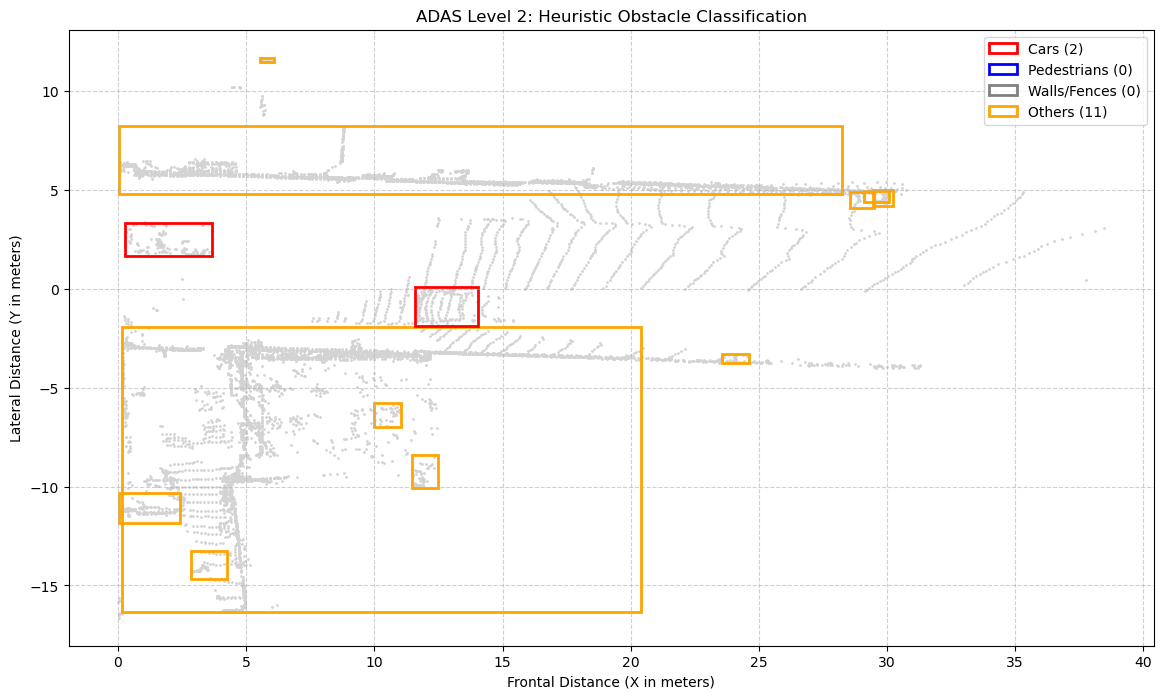

In [38]:
print("\nClassifying objects and generating image...")
points_obs = np.asarray(cloud_obstacles.points)

plt.figure(figsize=(14, 8))
mask = (points_obs[:, 0] > 0) & (points_obs[:, 0] < 40) & (np.abs(points_obs[:, 1]) < 20)

# Draw the base points in light gray so the boxes stand out
plt.scatter(points_obs[mask, 0], points_obs[mask, 1],
            c='lightgray', s=1) 

ax = plt.gca()

# Counters for statistics
counts = {"Cars": 0, "Pedestrians": 0, "Walls": 0, "Others": 0}

for i in range(max_label + 1):
    indices = np.where(labels[mask] == i)[0]
    if len(indices) == 0: continue

    points_object = points_obs[mask][indices]

    # --- EXTRACT 3D MEASUREMENTS ---
    min_x, max_x = np.min(points_object[:, 0]), np.max(points_object[:, 0])
    min_y, max_y = np.min(points_object[:, 1]), np.max(points_object[:, 1])
    min_z, max_z = np.min(points_object[:, 2]), np.max(points_object[:, 2]) # We add the height!

    # We calculate dimensions. 
    # Since the car can be rotated, we say the "length" is the longest side.
    dim_x = max_x - min_x
    dim_y = max_y - min_y
    
    length = max(dim_x, dim_y)
    width = min(dim_x, dim_y)
    height = max_z - min_z
    
    # We filter noise
    if length < 0.2 or width < 0.2 or height < 0.2:
        continue

    # RULE-BASED CLASSIFIER
    box_color = 'orange' # Default: Unknown
    
    # Cars
    if (2.0 < length < 6.5) and (1.5 < width < 2.5) and (1.0 < height < 2.5):
        box_color = 'red'
        counts["Cars"] += 1
        
    # Pedestrian / Cyclist
    elif (0.2 < length < 1.5) and (0.2 < width < 1.5) and (1.2 < height < 2.2):
        box_color = 'blue'
        counts["Pedestrians"] += 1
        
    # Rule: Wall / Fence / Guardrail
    elif (length > 3.0) and (width < 1.0):
        box_color = 'gray'
        counts["Walls"] += 1
        
    else:
        counts["Others"] += 1

    # Draw the Bounding boxes
    rect = patches.Rectangle((min_x, min_y), dim_x, dim_y,
                             linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)

legend = [
    patches.Patch(color='red', fill=False, linewidth=2, label=f'Cars ({counts["Cars"]})'),
    patches.Patch(color='blue', fill=False, linewidth=2, label=f'Pedestrians ({counts["Pedestrians"]})'),
    patches.Patch(color='gray', fill=False, linewidth=2, label=f'Walls/Fences ({counts["Walls"]})'),
    patches.Patch(color='orange', fill=False, linewidth=2, label=f'Others ({counts["Others"]})')
]
plt.legend(handles=legend, loc='upper right', fontsize=10)

# Final decoration
plt.title("ADAS Level 2: Heuristic Obstacle Classification")
plt.xlabel("Frontal Distance (X in meters)")
plt.ylabel("Lateral Distance (Y in meters)")
plt.grid(True, linestyle='--', alpha=0.6)

# Save and show
plt.savefig("output/05_obstacle_classification.png", dpi=150, bbox_inches='tight')
print(f"Classification finished. Results: {counts}")
plt.show()